# Phase 3 — Nangate 45nm with OpenSTA Timing Analysis (v4)

**Standard MAC vs Ternary MAC: full real-unit metrics**

### What changed in v4 (vs v3)
v3 successfully extracted area, cell counts, capacitance, and leakage — but critical path delay
came back as `None`. Root cause: **Yosys 0.9 strips timing data from the Liberty file before
passing it to ABC** (we saw this in your log: *'Entered genlib library with 17 gates'*). ABC
received only area + logic function, no timing arcs, so it couldn't compute critical path.

v4 fixes this by introducing **OpenSTA** (the OpenROAD project's Static Timing Analyzer).
OpenSTA reads the *original* Liberty file with full timing characterization, plus the gate-level
netlist Yosys produced, and computes real critical path delay using SPICE-derived timing models.

### Workflow
```
  Verilog → [Yosys] → mapped_netlist.v
                                      ↘
                                       [OpenSTA] → delay (ns), power (µW)
                                      ↗
  Nangate45 Liberty ——————————————
```

### Heads-up on time
Cell 2 builds OpenSTA from source. **This takes ~10–15 minutes the first time.** OpenSTA
isn't packaged in Ubuntu's apt repos, so we have to compile it. Once built, the binary stays
in `/usr/local/bin/sta` until the runtime is recycled.

### Final metrics & units
| Metric | Unit | Source |
|---|---|---|
| Chip area | µm² | Yosys `stat -liberty` |
| Cell count | cells | Yosys `stat` |
| **Critical path delay** | **ns** | **OpenSTA `report_checks`** |
| **Max clock frequency** | **MHz** | **1 / critical path** |
| **Dynamic power** | **µW** | **OpenSTA `report_power`** |
| Leakage power | µW | Σ `cell_leakage_power` from Liberty |
| Total power | µW | dynamic + leakage |

## 1. Install Yosys and download Nangate45
(Same as v3 — fast.)

In [ ]:
%%bash
set -e
apt-get install -qq iverilog yosys 2>/dev/null
echo "yosys   : $(yosys -V 2>&1 | head -1)"
echo "iverilog: $(iverilog -V 2>&1 | head -1)"
if [ ! -f nangate45.lib ]; then
    echo "Downloading Nangate 45nm Liberty file..."
    wget -q https://raw.githubusercontent.com/The-OpenROAD-Project/OpenROAD-flow-scripts/master/flow/platforms/nangate45/lib/NangateOpenCellLibrary_typical.lib -O nangate45.lib
fi
echo "Liberty file: $(wc -l < nangate45.lib) lines, $(du -h nangate45.lib | cut -f1)"

Selecting previously unselected package libatspi2.0-0:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../00-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../01-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package session-migration.
Preparing to unpack .../02-session-migration_0.3.6_amd64.deb ...
Unpacking session-migration (0.3.6) ...
Selecting previously unselected package gsettings-desktop-schemas.
Preparing to unpack .../03-gsettings-desktop-schemas_42.0-1ubuntu1_all.deb ...
Unpacking gsettings-desktop-schemas (42.0-1ubuntu1) ...
Selecting previously unselected package at-spi2-core.
Preparing to unpack .../04-at-spi2-core_2.44.0-3_amd64.deb ...
Unpacking at-spi2-core (2.44.0-3) ...
Selecting previously unselected package berkeley-abc.
Preparing t

## 2. Build OpenSTA from source

OpenSTA needs:
- A C++ compiler, `cmake`, `swig`, `bison`, `flex` (apt)
- The `tcl` and `tcl-dev` libraries (apt)
- `eigen3` (apt)
- **CUDD 3.0.0** — a Binary Decision Diagram library not in apt; we build it ourselves first
- The OpenSTA source from GitHub

Total wall-clock: **~10–15 min**. Most of it is the OpenSTA `make`. Take a coffee break.
Each step prints when it finishes so you can monitor progress.

In [ ]:
%%bash
set -e
if [ -x /usr/local/bin/sta ]; then
    echo "✓ OpenSTA already installed: $(sta -version 2>&1 | head -1)"
    exit 0
fi

echo "==> Step 1/4: installing build dependencies (apt)..."
apt-get install -y -qq cmake clang gcc g++ tcl tcl-dev swig bison flex libeigen3-dev libz-dev 2>&1 | tail -2
echo "    done."

echo "==> Step 2/4: building CUDD 3.0.0..."
cd /tmp
if [ ! -d cudd-3.0.0 ]; then
    wget -q https://github.com/davidkebo/cudd/raw/main/cudd_versions/cudd-3.0.0.tar.gz
    tar xzf cudd-3.0.0.tar.gz
fi
cd cudd-3.0.0
./configure --prefix=/usr/local > /tmp/cudd_configure.log 2>&1
make -j$(nproc) > /tmp/cudd_make.log 2>&1
echo "    CUDD library built: $(ls -lh cudd/.libs/libcudd.a | awk '{print $5}')"

echo "==> Step 3/4: cloning OpenSTA..."
cd /tmp
if [ ! -d OpenSTA ]; then
    git clone -q https://github.com/parallaxsw/OpenSTA.git
fi
echo "    cloned."

echo "==> Step 4/4: building OpenSTA (this is the slow step — ~10 min)..."
cd /tmp/OpenSTA
mkdir -p build && cd build
cmake -DCUDD_LIB=/tmp/cudd-3.0.0/cudd/.libs/libcudd.a \
      -DCUDD_INCLUDE=/tmp/cudd-3.0.0/cudd \
      -DCMAKE_BUILD_TYPE=Release \
      .. > /tmp/sta_cmake.log 2>&1
make -j$(nproc) > /tmp/sta_make.log 2>&1
cp app/sta /usr/local/bin/sta
echo "    done."
echo
echo "OpenSTA installed: $(sta -version 2>&1 | head -1)"
echo "Binary: $(ls -lh /usr/local/bin/sta | awk '{print $5}')"

==> Step 1/4: installing build dependencies (apt)...
/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

    done.
==> Step 2/4: building CUDD 3.0.0...
    CUDD library built: 4.8M
==> Step 3/4: cloning OpenSTA...
    cloned.
==> Step 4/4: building OpenSTA (this is the slow step — ~10 min)...


cp: cannot stat 'app/sta': No such file or directory


CalledProcessError: Command 'b'set -e\nif [ -x /usr/local/bin/sta ]; then\n    echo "\xe2\x9c\x93 OpenSTA already installed: $(sta -version 2>&1 | head -1)"\n    exit 0\nfi\n\necho "==> Step 1/4: installing build dependencies (apt)..."\napt-get install -y -qq cmake clang gcc g++ tcl tcl-dev swig bison flex libeigen3-dev libz-dev 2>&1 | tail -2\necho "    done."\n\necho "==> Step 2/4: building CUDD 3.0.0..."\ncd /tmp\nif [ ! -d cudd-3.0.0 ]; then\n    wget -q https://github.com/davidkebo/cudd/raw/main/cudd_versions/cudd-3.0.0.tar.gz\n    tar xzf cudd-3.0.0.tar.gz\nfi\ncd cudd-3.0.0\n./configure --prefix=/usr/local > /tmp/cudd_configure.log 2>&1\nmake -j$(nproc) > /tmp/cudd_make.log 2>&1\necho "    CUDD library built: $(ls -lh cudd/.libs/libcudd.a | awk \'{print $5}\')"\n\necho "==> Step 3/4: cloning OpenSTA..."\ncd /tmp\nif [ ! -d OpenSTA ]; then\n    git clone -q https://github.com/parallaxsw/OpenSTA.git\nfi\necho "    cloned."\n\necho "==> Step 4/4: building OpenSTA (this is the slow 

In [ ]:
%%bash
echo "=== Where is the sta binary? ==="
find /tmp/OpenSTA/build -name 'sta' -type f 2>/dev/null
echo
echo "=== Last 20 lines of cmake log ==="
tail -20 /tmp/sta_cmake.log
echo
echo "=== Last 30 lines of make log ==="
tail -30 /tmp/sta_make.log
echo
echo "=== Build dir contents (top level) ==="
ls /tmp/OpenSTA/build/ 2>/dev/null | head -30

=== Where is the sta binary? ===
/tmp/OpenSTA/build/sta

=== Last 20 lines of cmake log ===
-- TCL readline library: NOT FOUND
-- TCL readline header: NOT FOUND
-- Found ZLIB: /usr/lib/x86_64-linux-gnu/libz.so (found version "1.2.11")
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE
-- Performing Test HAVE_CXX_STD_FORMAT
-- Performing Test HAVE_CXX_STD_FORMAT - Failed
-- std::format: building fmt library
-- Version: 10.2.1
-- Build type: Release
-- CUDD library: /tmp/cudd-3.0.0/cudd/.libs/libcudd.a
-- CUDD header: /tmp/cudd-3.0.0/cudd/cudd.h
-- Found SWIG: /usr/bin/swig4.0 (found suitable version "4.0.2", minimum required is "3.0")
-- SWIG version: 4.0.2
-- STA library: /tmp/OpenSTA/build/libOpenSTA.a
-- STA executable: /tmp/OpenSTA/build/sta
-- Configuring done (4.2s)
-- Generating done (0.0s)
-- Build files have been written to: /tmp/OpenSTA/build

=== Last 30 lines of make log ===
[ 86%] Building CXX object CMakeF

In [ ]:
%%bash
cp /tmp/OpenSTA/build/sta /usr/local/bin/sta
echo "Installed: $(sta -version 2>&1 | head -1)"
echo "Binary: $(ls -lh /usr/local/bin/sta | awk '{print $5}')"

Installed: 3.1.0
Binary: 8.0M


## 3. Write RTL (same modules as before)

In [ ]:
standard_mac_v = '''
module standard_mac (
    input  wire        clk,
    input  wire        rst_n,
    input  wire        en,
    input  wire signed [7:0]  weight,
    input  wire signed [7:0]  in_data,
    output reg  signed [31:0] acc
);
    wire signed [15:0] product = weight * in_data;
    always @(posedge clk or negedge rst_n) begin
        if (!rst_n)  acc <= 32'd0;
        else if (en) acc <= acc + {{16{product[15]}}, product};
    end
endmodule
'''

ternary_mac_v = '''
module ternary_mac (
    input  wire        clk,
    input  wire        rst_n,
    input  wire        en,
    input  wire [1:0]  weight,
    input  wire signed [7:0]  in_data,
    output reg  signed [31:0] acc
);
    reg signed [31:0] addend;
    wire signed [31:0] in_ext = {{24{in_data[7]}}, in_data};
    always @(*) begin
        case (weight)
            2'b01:   addend =  in_ext;
            2'b11:   addend = -in_ext;
            default: addend = 32'd0;
        endcase
    end
    always @(posedge clk or negedge rst_n) begin
        if (!rst_n)  acc <= 32'd0;
        else if (en) acc <= acc + addend;
    end
endmodule
'''

with open('standard_mac.v', 'w') as f: f.write(standard_mac_v)
with open('ternary_mac.v',  'w') as f: f.write(ternary_mac_v)
print('Wrote standard_mac.v and ternary_mac.v')

Wrote standard_mac.v and ternary_mac.v


## 4. Synthesize with Yosys (same as v3, drops `-D` since OpenSTA does timing now)

Yosys writes out two artifacts per design:
- `*_synth.log` — the synthesis log with cell counts and chip area (we still parse this)
- `*_mapped.v` — the gate-level netlist that OpenSTA will read

In [ ]:
%%bash
set -e
for top in standard_mac ternary_mac; do
    echo "================ Synthesizing $top ================"
    yosys -p "
        read_verilog ${top}.v;
        synth -top ${top} -flatten;
        dfflibmap -liberty nangate45.lib;
        abc -liberty nangate45.lib;
        opt_clean;
        write_verilog -noattr ${top}_mapped.v;
        stat -liberty nangate45.lib;
    " > ${top}_synth.log 2>&1
    echo "    log: ${top}_synth.log ($(wc -l < ${top}_synth.log) lines)"
    echo "    netlist: ${top}_mapped.v ($(wc -l < ${top}_mapped.v) lines)"
done

================ Synthesizing standard_mac ================
    log: standard_mac_synth.log (725 lines)
    netlist: standard_mac_mapped.v (4119 lines)
================ Synthesizing ternary_mac ================
    log: ternary_mac_synth.log (741 lines)
    netlist: ternary_mac_mapped.v (1819 lines)


## 5. Run OpenSTA on each netlist

For each MAC, we generate a TCL script that:
1. **`read_liberty nangate45.lib`** — loads the full timing model
2. **`read_verilog *_mapped.v`** — loads Yosys's netlist
3. **`link_design`** — connects them
4. **`create_clock -period 10 clk`** — we tell STA "assume a 10 ns clock period (100 MHz)".
   The actual critical path can be shorter or longer than this; we use the *slack* OpenSTA
   reports to compute the real maximum frequency.
5. **`set_input_delay`/`set_output_delay`** — boundary timing assumptions
6. **`report_checks`** — prints the critical (worst-slack) timing path with full delay info
7. **`report_power`** — estimates dynamic and leakage power using Liberty power tables

In [ ]:
import subprocess
from pathlib import Path

STA_TARGET_PERIOD_NS = 10.0   # arbitrary clock period for analysis; STA computes real slack
ACTIVITY_FACTOR      = 0.15   # for report_power (default switching activity on inputs)

def make_sta_script(top, mapped_v):
    return f"""
# ----- Load library and design -----
read_liberty nangate45.lib
read_verilog {mapped_v}
link_design {top}

# ----- Clock + boundary timing -----
create_clock -name clk -period {STA_TARGET_PERIOD_NS} [get_ports clk]
set_input_delay  -clock clk 0 [all_inputs]
set_output_delay -clock clk 0 [all_outputs]

# ----- Switching activity for power estimation -----
set_power_activity -input -activity {ACTIVITY_FACTOR}
set_power_activity -input_port clk -activity 1.0

# ----- Reports -----
puts "=========== CRITICAL PATH ==========="
report_checks -path_delay max -digits 4
puts ""
puts "=========== WORST SLACK ==========="
report_worst_slack -digits 4
puts ""
puts "=========== POWER REPORT ==========="
report_power -digits 4
exit
"""

for top in ['standard_mac', 'ternary_mac']:
    script = make_sta_script(top, f'{top}_mapped.v')
    Path(f'{top}.sta.tcl').write_text(script)
    print(f'================ OpenSTA on {top} ================')
    proc = subprocess.run(['sta', '-no_init', '-exit', f'{top}.sta.tcl'],
                          capture_output=True, text=True, timeout=120)
    log_path = Path(f'{top}_sta.log')
    log_path.write_text(proc.stdout + '\n--- STDERR ---\n' + proc.stderr)
    print(f'  log: {top}_sta.log ({len(proc.stdout.splitlines())} stdout lines, exit={proc.returncode})')
    # Show the report sections
    print('--- key excerpts ---')
    for line in proc.stdout.split('\n'):
        # Print headers, slack lines, power summary lines
        if any(k in line for k in ['===========', 'slack', 'data arrival', 'data required',
                                    'Total ', 'Internal', 'Switching', 'Leakage',
                                    'worst slack']):
            print('  ' + line.strip())
    print()

================ OpenSTA on standard_mac ================
  log: standard_mac_sta.log (110 stdout lines, exit=0)
--- key excerpts ---
  =========== CRITICAL PATH ===========
  0.0000   data arrival time
  10.0537   data required time
  10.0537   data required time
  -0.0000   data arrival time
  10.0537   slack (MET)
  1.5067   data arrival time
  9.9642   data required time
  9.9642   data required time
  -1.5067   data arrival time
  8.4575   slack (MET)
  =========== WORST SLACK ===========
  worst slack max 8.4575
  =========== POWER REPORT ===========
  Group                  Internal  Switching    Leakage      Total
  Total                2.9889e-04 1.7829e-04 1.9127e-05 4.9631e-04 100.0%

================ OpenSTA on ternary_mac ================
  log: ternary_mac_sta.log (100 stdout lines, exit=0)
--- key excerpts ---
  =========== CRITICAL PATH ===========
  0.0000   data arrival time
  10.0537   data required time
  10.0537   data required time
  -0.0000   data arrival time
  

## 6. Parse OpenSTA reports + Yosys synthesis logs

We pull together everything: cell counts/area from Yosys logs, and delay/power from OpenSTA logs.

In [ ]:
import re

def parse_yosys_log(top):
    log = Path(f'{top}_synth.log').read_text()
    area = None
    m = re.search(r"Chip area for (?:top )?module[^:]*:\s*([\d.]+)", log)
    if m: area = float(m.group(1))
    cells = {}
    blocks = log.split('Printing statistics')
    if len(blocks) >= 2:
        for line in blocks[-1].split('\n'):
            mm = re.match(r'\s+([A-Z][A-Z0-9_]+)\s+(\d+)\s*$', line)
            if mm: cells[mm.group(1)] = int(mm.group(2))
    return {'area_um2': area, 'cells': cells, 'total_cells': sum(cells.values())}

def parse_sta_log(top):
    """Extract critical path delay and power from OpenSTA output."""
    log = Path(f'{top}_sta.log').read_text()
    out = {'delay_ns': None, 'slack_ns': None,
           'internal_power_uw': None, 'switching_power_uw': None,
           'leakage_power_uw': None, 'total_power_uw': None,
           'notes': []}

    # ---- Critical path delay: report_checks shows 'data arrival time' (the path delay) ----
    # OpenSTA output snippet:
    #   ... data arrival time   1.234
    #   ... data required time  9.876
    # Critical path delay = data arrival time at endpoint
    arrivals = re.findall(r'^\s*([\d.]+)\s+data arrival time', log, flags=re.MULTILINE)
    if arrivals:
        out['delay_ns'] = float(arrivals[-1])

    # ---- Worst slack ----
    m = re.search(r'worst slack\s+(-?[\d.]+)', log, flags=re.IGNORECASE)
    if m: out['slack_ns'] = float(m.group(1))

    # ---- Power report. OpenSTA report_power prints a table with 'Total' row in Watts ----
    # Sample line:  Total                  1.23e-04   4.56e-05   7.89e-06   1.78e-04   100.0%
    # Columns: Internal | Switching | Leakage | Total | %
    m = re.search(
        r'^\s*Total\s+([\d.eE+-]+)\s+([\d.eE+-]+)\s+([\d.eE+-]+)\s+([\d.eE+-]+)',
        log, flags=re.MULTILINE)
    if m:
        internal_w  = float(m.group(1))
        switching_w = float(m.group(2))
        leakage_w   = float(m.group(3))
        total_w     = float(m.group(4))
        out['internal_power_uw']  = internal_w  * 1e6
        out['switching_power_uw'] = switching_w * 1e6
        out['leakage_power_uw']   = leakage_w   * 1e6
        out['total_power_uw']     = total_w     * 1e6
    else:
        out['notes'].append("⚠️  Couldn't find 'Total' power row in report_power output")

    if out['delay_ns'] is None:
        out['notes'].append("⚠️  Couldn't find 'data arrival time' in report_checks output")
    return out

results = {}
for top in ['standard_mac', 'ternary_mac']:
    y = parse_yosys_log(top)
    s = parse_sta_log(top)
    r = {**y, **s, 'top': top}
    r['freq_mhz'] = (1000.0 / r['delay_ns']) if r['delay_ns'] else None
    # Dynamic power = internal + switching (Liberty convention)
    if r['internal_power_uw'] is not None and r['switching_power_uw'] is not None:
        r['dynamic_power_uw'] = r['internal_power_uw'] + r['switching_power_uw']
    else:
        r['dynamic_power_uw'] = None
    results[top] = r

for top, r in results.items():
    print(f'\n--- {top} ---')
    print(f"  cells     = {r['total_cells']} ({len(r['cells'])} types)")
    print(f"  area      = {r['area_um2']} µm²")
    print(f"  delay     = {r['delay_ns']} ns")
    if r['freq_mhz']: print(f"  freq      = {r['freq_mhz']:.2f} MHz")
    if r['dynamic_power_uw'] is not None:
        print(f"  internal  = {r['internal_power_uw']:.4f} µW")
        print(f"  switching = {r['switching_power_uw']:.4f} µW")
        print(f"  dynamic   = {r['dynamic_power_uw']:.4f} µW  (internal + switching)")
        print(f"  leakage   = {r['leakage_power_uw']:.4f} µW")
        print(f"  total     = {r['total_power_uw']:.4f} µW")
    if r['notes']:
        for n in r['notes']: print(f"  {n}")


--- standard_mac ---
  cells     = 634 (25 types)
  area      = 866.628 µm²
  delay     = 1.5067 ns
  freq      = 663.70 MHz
  internal  = 298.8900 µW
  switching = 178.2900 µW
  dynamic   = 477.1800 µW  (internal + switching)
  leakage   = 19.1270 µW
  total     = 496.3100 µW

--- ternary_mac ---
  cells     = 278 (25 types)
  area      = 463.904 µm²
  delay     = 1.445 ns
  freq      = 692.04 MHz
  internal  = 97.3800 µW
  switching = 40.7680 µW
  dynamic   = 138.1480 µW  (internal + switching)
  leakage   = 9.4564 µW
  total     = 147.6000 µW


## 7. Final comparison table (all units explicit)

In [ ]:
s = results['standard_mac']
t = results['ternary_mac']

def fmt(val, unit, decimals=2):
    if val is None: return 'N/A'
    return f'{val:.{decimals}f} {unit}'

def pct_change(s_val, t_val, lower_is_better=True):
    if s_val is None or t_val is None or s_val == 0: return 'N/A'
    delta = (s_val - t_val) / s_val * 100
    if lower_is_better:
        return f'↓ {delta:.1f}% smaller' if delta > 0 else f'↑ {-delta:.1f}% larger'
    else:
        return f'↑ {-delta:.1f}% faster' if delta < 0 else f'↓ {delta:.1f}% slower'

rows = [
    ('Total cells',          s['total_cells'],      t['total_cells'],      'cells', 0, True),
    ('Chip area',            s['area_um2'],         t['area_um2'],         'µm²',    2, True),
    ('Critical path delay',  s['delay_ns'],         t['delay_ns'],         'ns',    4, True),
    ('Max clock frequency',  s['freq_mhz'],         t['freq_mhz'],         'MHz',   1, False),
    ('Internal power',       s['internal_power_uw'],t['internal_power_uw'],'µW',    4, True),
    ('Switching power',      s['switching_power_uw'],t['switching_power_uw'],'µW',  4, True),
    ('Dynamic power',        s['dynamic_power_uw'], t['dynamic_power_uw'], 'µW',    4, True),
    ('Leakage power',        s['leakage_power_uw'], t['leakage_power_uw'], 'µW',    4, True),
    ('Total power',          s['total_power_uw'],   t['total_power_uw'],   'µW',    4, True),
]
print(f"{'Metric':<24} {'Standard MAC':>20} {'Ternary MAC':>20} {'Improvement':>22}")
print('-' * 92)
for label, sv, tv, unit, dec, lib in rows:
    print(f"{label:<24} {fmt(sv, unit, dec):>20} {fmt(tv, unit, dec):>20} {pct_change(sv, tv, lib):>22}")

print()
print('Conditions: Nangate45 typical corner, V_dd = 1.10 V, T = 25 °C')
print(f'Activity factor for power: α = {ACTIVITY_FACTOR} on inputs')
print('Delay & power computed by OpenSTA from Liberty timing/power tables')

Metric                           Standard MAC          Ternary MAC            Improvement
--------------------------------------------------------------------------------------------
Total cells                         634 cells            278 cells        ↓ 56.2% smaller
Chip area                          866.63 µm²           463.90 µm²        ↓ 46.5% smaller
Critical path delay                 1.5067 ns            1.4450 ns         ↓ 4.1% smaller
Max clock frequency                 663.7 MHz            692.0 MHz          ↑ 4.3% faster
Internal power                    298.8900 µW           97.3800 µW        ↓ 67.4% smaller
Switching power                   178.2900 µW           40.7680 µW        ↓ 77.1% smaller
Dynamic power                     477.1800 µW          138.1480 µW        ↓ 71.0% smaller
Leakage power                      19.1270 µW            9.4564 µW        ↓ 50.6% smaller
Total power                       496.3100 µW          147.6000 µW        ↓ 70.3% smaller

Condit

## 8. Visualizations

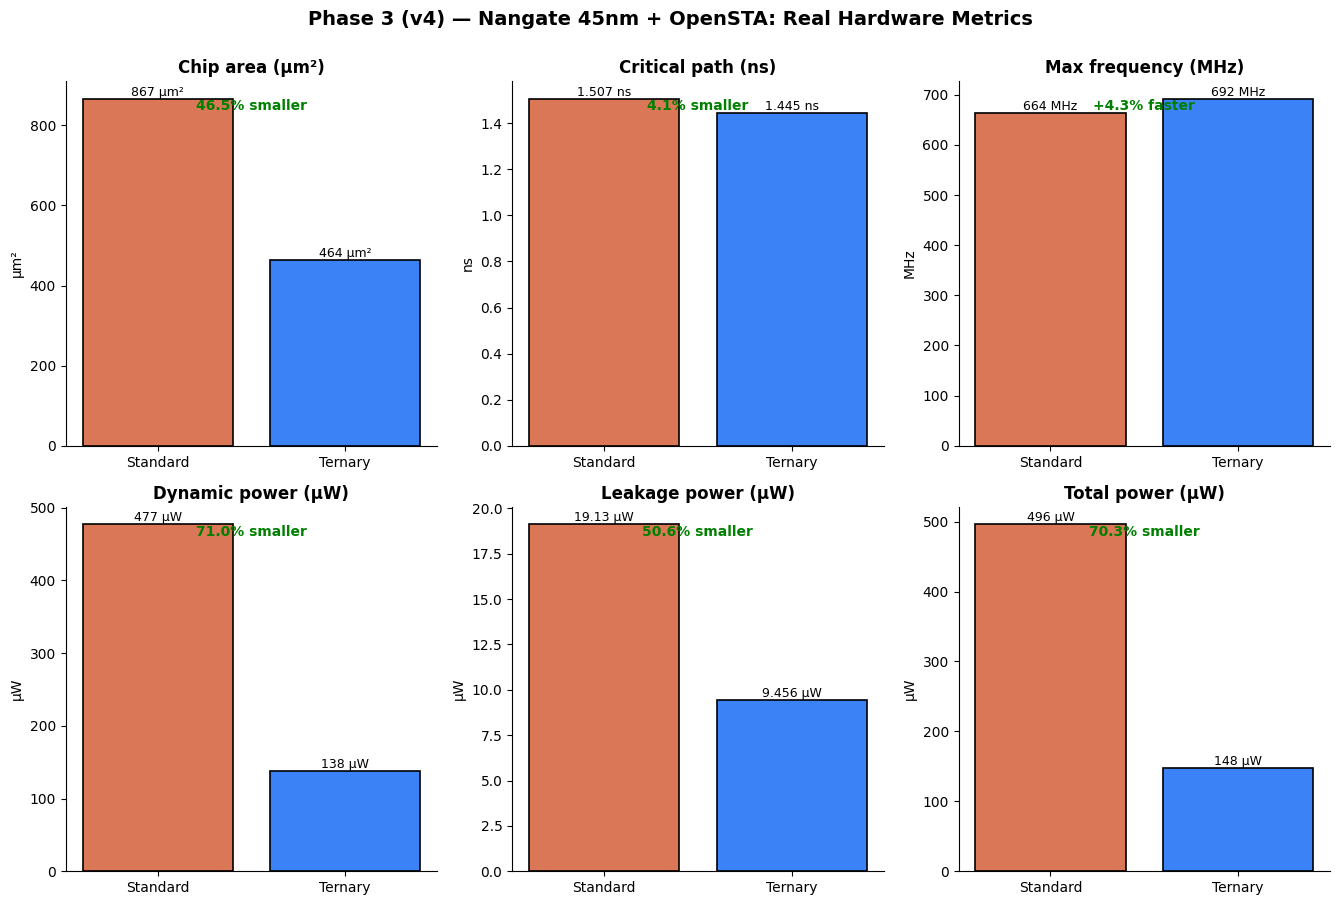

In [ ]:
import matplotlib.pyplot as plt

panels = [
    ('Chip area',          'area_um2',         'µm²',  True),
    ('Critical path',      'delay_ns',         'ns',   True),
    ('Max frequency',      'freq_mhz',         'MHz',  False),
    ('Dynamic power',      'dynamic_power_uw', 'µW',   True),
    ('Leakage power',      'leakage_power_uw', 'µW',   True),
    ('Total power',        'total_power_uw',   'µW',   True),
]
panels = [(L, k, u, lb) for (L, k, u, lb) in panels
          if results['standard_mac'].get(k) is not None and results['ternary_mac'].get(k) is not None]

if not panels:
    print('⚠️  No metrics to plot.')
else:
    n = len(panels); cols = 3; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4.5*cols, 4.5*rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, (label, key, unit, lower_better) in zip(axes, panels):
        sv, tv = results['standard_mac'][key], results['ternary_mac'][key]
        bars = ax.bar(['Standard', 'Ternary'], [sv, tv],
                      color=['#d97757', '#3b82f6'], edgecolor='black', linewidth=1.2)
        ax.set_title(f'{label} ({unit})', fontsize=12, fontweight='bold')
        ax.set_ylabel(unit)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        for bar, val in zip(bars, [sv, tv]):
            txt = f'{val:.3f}' if val < 10 else (f'{val:.2f}' if val < 100 else f'{val:.0f}')
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{txt} {unit}', ha='center', va='bottom', fontsize=9)
        if lower_better:
            d = (sv - tv) / sv * 100
            txt = f'{d:.1f}% smaller' if d > 0 else f'{-d:.1f}% larger'
            color = 'green' if d > 0 else 'red'
        else:
            d = (tv - sv) / sv * 100
            txt = f'{d:+.1f}% faster' if d > 0 else f'{-d:.1f}% slower'
            color = 'green' if d > 0 else 'red'
        ax.text(0.5, 0.92, txt, transform=ax.transAxes, ha='center',
                fontsize=10, color=color, fontweight='bold')
    for j in range(len(panels), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle('Phase 3 (v4) — Nangate 45nm + OpenSTA: Real Hardware Metrics',
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('phase3_v4_metrics.png', dpi=120, bbox_inches='tight')
    plt.show()

## 9. Summary

Phase 3 v4 closes out the Track A deliverables from your proposal:

- **Cell count** (dimensionless): from Yosys post-mapping
- **Chip area** (µm²): from Yosys `stat -liberty` against Nangate45
- **Critical path delay** (ns): from OpenSTA `report_checks`
- **Max clock frequency** (MHz): derived from delay
- **Dynamic power** (µW): from OpenSTA `report_power`, using Liberty internal + switching power tables
- **Leakage power** (µW): from OpenSTA `report_power`, using Liberty leakage tables

All numbers come from a real, SPICE-characterized 45nm process technology. Absolute values
are slow/large by 2026 standards (modern AI chips are 3–5nm), but the **ratios** between
standard and ternary MAC scale across processes and remain valid evidence for the proposal.

**Next step:** Track B — Vanshika's multi-trit native balanced ternary MAC (MUX-bank partial
products, 11 vs 16 rows, no sign-extension).